In [1]:
import os
import sys
from pathlib import Path
import time

if os.getcwd().endswith("scripts"):
    os.chdir("..")
sys.path.insert(0, "src")

import yaml
import torch

from utils import resolve_device, set_seed, plot_history
from data import get_loaders
from models import PlainCNN



In [2]:
config_path = "configs.yaml"
with open(config_path, "r") as f:   
    cfg = yaml.safe_load(f)

device = resolve_device(cfg["device"])
print(f"Device: {device}")

SEED = cfg.get("seed", 42)
set_seed(SEED)
print(f"Random seed set to: {SEED}")


Device: xpu
Random seed set to: 42


In [3]:
train_loader, test_loader = get_loaders(
    data_dir="data",
    batch_size=cfg["data"]["batch_size"],
    num_workers=cfg["data"]["num_workers"]
)

print(f"Number of training batches: {len(train_loader)}")
print(f"Number of testing batches: {len(test_loader)}")


Number of training batches: 782
Number of testing batches: 157


In [4]:
plain_cnn = PlainCNN(num_classes=cfg["model"]["num_classes"]).to(device)
plain_cnn_optimizer = torch.optim.Adam(plain_cnn.parameters(), lr=1e-3)

criterion = torch.nn.CrossEntropyLoss()

print(plain_cnn)
print(f"Number of parameters: {sum(p.numel() for p in plain_cnn.parameters())}")

PlainCNN(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block3): Sequential(
    (0): Conv2d(64, 128

In [5]:
def train_one_epoch(model, optimizer, criterion, loader, device):
    """returns: avg_loss, avg_acc"""
    model.train()
    total_loss = 0
    total_correct = 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        preds = logits.argmax(dim=1)
        total_correct += (preds == yb).sum().item()
        
        total_loss += loss.item()
    
    avg_loss = total_loss / len(loader)
    avg_acc = total_correct / len(loader.dataset)

    return avg_loss, avg_acc


def test_one_epoch(model, criterion, loader, device):
    """returns: avg_loss, avg_acc"""
    model.eval()
    total_loss = 0
    total_correct = 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)

            logits = model(xb) 
            loss = criterion(logits, yb)
            preds = logits.argmax(dim=1)

            total_correct += (preds == yb).sum().item()
            total_loss += loss.item()

    avg_loss = total_loss / len(loader)
    avg_acc = total_correct / len(loader.dataset)

    return avg_loss, avg_acc


def train(model, optimizer, criterion, train_loader, test_loader, device, epochs=10):
    history = {}
    history["train_loss"] = []
    history["train_acc"] = []
    history["test_loss"] = []
    history["test_acc"] = []

    format_n = len(str(epochs))
    
    for epoch in range(epochs):
        start = time.time()
        ts = time.strftime("%H:%M:%S", time.localtime(start))

        train_loss, train_acc = train_one_epoch(model, optimizer, criterion, train_loader, device)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)

        test_loss, test_acc = test_one_epoch(model, criterion, test_loader, device)

        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)

        duration = time.time() - start

        print(
            f"[{ts}]: {epoch+1:0{format_n}d}/{epochs} - "
            f"Train: [{train_loss:.4f}, {train_acc:.4f}] | "
            f"Test: [{test_loss:.4f}, {test_acc:.4f}] - "
            f"{duration:.2f}s"
        )

    return history



[19:33:33]: 01/10 - Train: [1.1960, 0.5683] | Test: [1.0440, 0.6290] - 21.18s
[19:33:54]: 02/10 - Train: [0.8179, 0.7124] | Test: [0.8017, 0.7137] - 17.81s
[19:34:12]: 03/10 - Train: [0.6502, 0.7739] | Test: [0.7056, 0.7556] - 17.89s
[19:34:30]: 04/10 - Train: [0.5485, 0.8090] | Test: [0.6152, 0.7938] - 17.94s
[19:34:48]: 05/10 - Train: [0.4805, 0.8348] | Test: [0.5257, 0.8153] - 18.19s
[19:35:06]: 06/10 - Train: [0.4256, 0.8521] | Test: [0.5494, 0.8123] - 18.38s
[19:35:24]: 07/10 - Train: [0.3751, 0.8706] | Test: [0.5706, 0.8046] - 25.58s
[19:35:50]: 08/10 - Train: [0.3334, 0.8838] | Test: [0.6959, 0.7852] - 21.26s
[19:36:11]: 09/10 - Train: [0.2976, 0.8973] | Test: [0.6679, 0.7811] - 18.14s
[19:36:29]: 10/10 - Train: [0.2627, 0.9094] | Test: [0.5988, 0.8084] - 18.80s


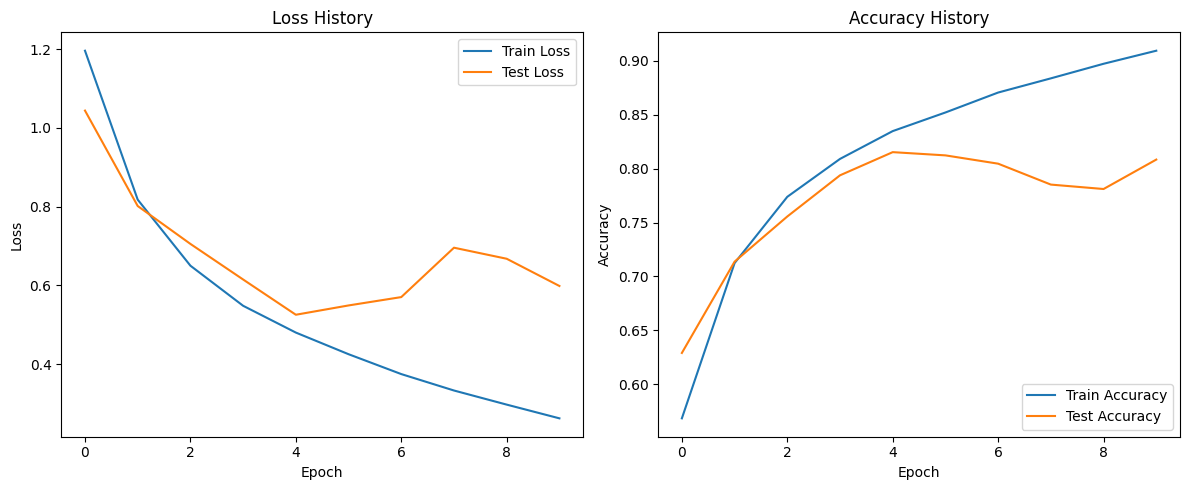

In [6]:
epochs = cfg.get("train", {}).get("epochs", 10)

history = train(
    model=plain_cnn,
    optimizer=plain_cnn_optimizer,
    criterion=criterion,
    train_loader=train_loader,
    test_loader=test_loader,
    device=device,
    epochs=epochs,
)

plot_history(history)
